In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np

# Read data
csv_path = Path("DST_BIL54.csv")

df = pd.read_csv(csv_path)

# Parse monthly timestamp (YYYY-MM -> first day of month)
df["time"] = pd.to_datetime(df["time"] + "-01", format="%Y-%m-%d", utc=True)

# Fractional year: 2018-Jan = 2018, 2018-Feb = 2018 + 1/12, ...
df["x"] = df["time"].dt.year + (df["time"].dt.month - 1) / 12

# Make output variable a floating point in millions
df["total"] = pd.to_numeric(df["total"], errors="coerce") / 1e6

# Train/test split
teststart = pd.Timestamp("2024-01-01", tz="UTC")
dtrain = df[df["time"] < teststart].copy()
_dtest = df[df["time"] >= teststart].copy()

# x, y from training set
dtrain["x0"] = dtrain["x"] - 2018.0
x = dtrain["x0"].to_numpy()
y = dtrain["total"].to_numpy()
N = len(x)


# Implement algorithm

In [ ]:
def rls_step(theta_prior, R_prior, x, y):
    R = R_prior + x.T @ x # Formula 11.13b
    theta = theta_prior + np.linalg.inv(R) @ x.T * (y - x @ theta_prior) # Formula 11.13a

    return theta, R

In [17]:
x = dtrain["x0"].to_numpy()
y = dtrain["total"].to_numpy()
R0 = np.array([[0.1, 0.0],
            [0.0, 0.1]])
theta0 = np.zeros((2, 1)).astype(float)
N = len(x)

for i in range(N):
    xi = x[i]
    yi = y[i]
    
    X_t = np.array([[1.0, xi]])
    y_t = np.array([[yi]])

    theta, R = rls_step(theta0, R0, X_t, y_t)
    theta0 = theta
    R0 = R

    if i < 5 or i > N - 5:
        print(f"i {i} xi: {theta[0]}, yi: {theta[1]}")


i 0 xi: [2.66407545], yi: [0.]
i 1 xi: [2.78811971], yi: [0.11370724]
i 2 xi: [2.82332316], yi: [0.21458877]
i 3 xi: [2.83295876], yi: [0.28463215]
i 4 xi: [2.83418567], yi: [0.31943171]
i 68 xi: [2.92339872], yi: [0.0627649]
i 69 xi: [2.92513183], yi: [0.0618445]
i 70 xi: [2.92684803], yi: [0.06094635]
i 71 xi: [2.92843395], yi: [0.06012827]


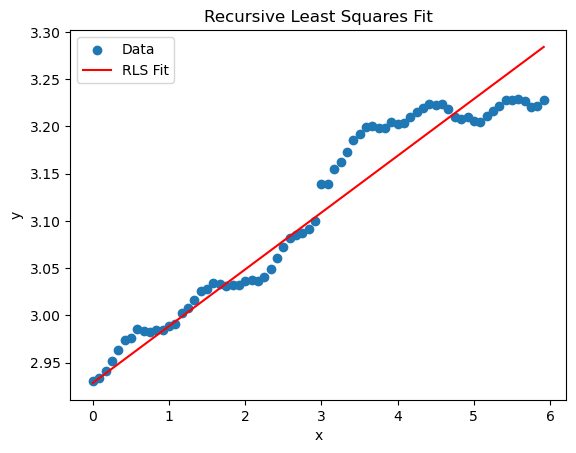

In [9]:
# Plot the function against the data
plt.scatter(x, y, label="Data")
x_plot = np.linspace(x.min(), x.max(), 100)
X_plot = np.column_stack((np.ones_like(x_plot), x_plot))
y_plot = X_plot @ theta
plt.plot(x_plot, y_plot, color="red", label="RLS Fit")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Recursive Least Squares Fit")
plt.legend()
plt.show()


# 5.4 - Adding forgetting factor

In [14]:
def rls_step_forget(theta_prior, R_prior, x, y, lambda_):
    R = lambda_ * R_prior + x.T @ x # Formula 11.13b
    theta = theta_prior + np.linalg.inv(R) @ x.T * (y - x @ theta_prior) # Formula 11.13a

    return theta, R

In [ ]:
lst_theta_per_factor = []
forgetting_factor = [0.99, 0.7]

for i in range(len(forgetting_factor)):
    lst_theta = []
    for j in range(N):
        xi = x[j]
        yi = y[j]
        
        X_t = np.array([[1.0, xi]])
        y_t = np.array([[yi]])

        # Run the step form book 11.30a and 11.30b
        theta, R = rls_step_forget(theta0, R0, X_t, y_t, forgetting_factor[i])
        theta0 = theta
        R0 = R

        lst_theta.append(theta)
    print(f"i {i} xi: {lst_theta[j][0]}, yi: {lst_theta[j][1]}")
    lst_theta_per_factor.append(lst_theta)

print(lst_theta_per_factor[0][N-1])
print(lst_theta_per_factor[1][N-1])

i 0 xi: [2.95127897], yi: [0.05363184]
i 1 xi: [3.17066301], yi: [0.00937098]
[[2.95127897]
 [0.05363184]]
[[3.17066301]
 [0.00937098]]


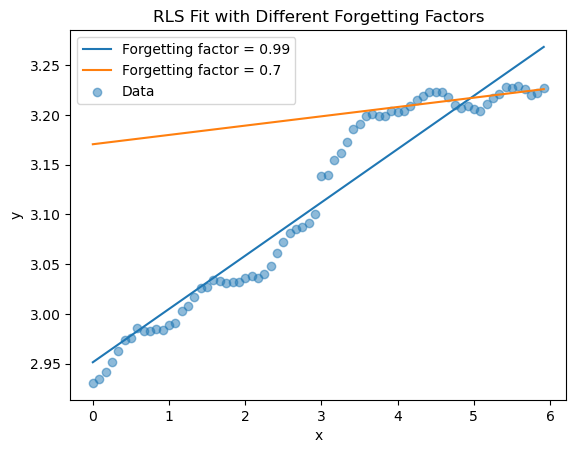

In [49]:
# Plot all thetas in lst_theta
for i, theta_vals in enumerate(lst_theta_per_factor):
    y_plot = X_plot @ theta_vals[N-1]
    plt.plot(x_plot, y_plot, label=f"Forgetting factor = {forgetting_factor[i]}")

plt.scatter(x, y, label="Data", alpha=0.5)
plt.xlabel("x")
plt.ylabel("y")
plt.title("RLS Fit with Different Forgetting Factors")
plt.legend()
plt.show()

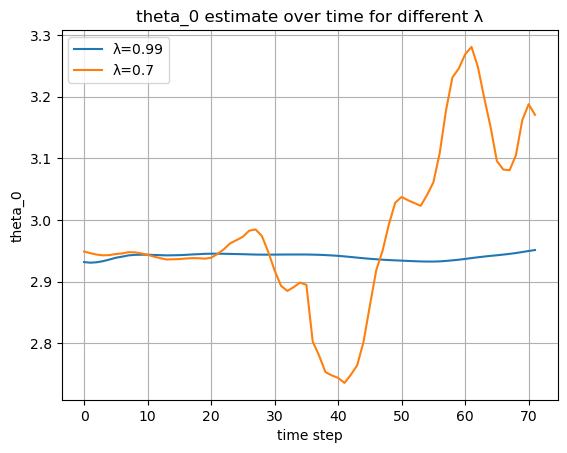

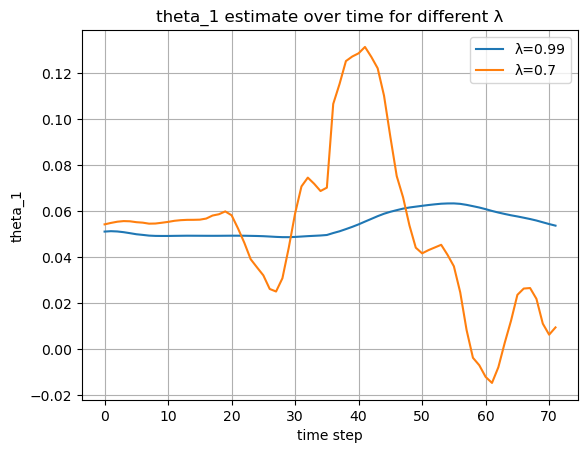

In [52]:

theta_arrays = []
for theta_list in lst_theta_per_factor:
    # hstack along the second axis produces a (2, N) array
    theta_arrays.append(np.hstack(theta_list))
theta_arrays = np.array(theta_arrays)   # shape (n_factors, 2, N)

param_names = ['theta_0', 'theta_1']
for p in range(2):
    plt.figure()
    for k, lam in enumerate(forgetting_factor):
        plt.plot(range(N), theta_arrays[k, p, :], label=f"λ={lam}")
    plt.xlabel('time step')
    plt.ylabel(param_names[p])
    plt.title(f"{param_names[p]} estimate over time for different λ")
    plt.legend()
    plt.grid(True)
    plt.show()